# 04 — Quantization v3 (8-feature model, per-user norm)

Converts best v3 model to INT8 TFLite and generates C headers.  
Config includes per-user normalization note and 8 feature channels.

In [1]:
import numpy as np
import pickle
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.13.0


## 1. Load Model and Data

In [2]:
DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models')

with open(DATA_DIR / 'preprocessing_info.pkl', 'rb') as f:
    info = pickle.load(f)

with open(MODEL_DIR / 'training_info_v3.pkl', 'rb') as f:
    train_info = pickle.load(f)

ACTIVITIES = info['activities']
NUM_CLASSES = info['num_classes']
SENSOR_COLS = info['sensor_columns']
RAW_SENSOR_COLS = info['raw_sensor_columns']
SENSOR_MEAN = info['sensor_mean']
SENSOR_STD = info['sensor_std']
WINDOW_SIZE = info['window_size']
SAMPLING_RATE = info['sampling_rate']
NUM_FEATURES = info['num_features']

print(f'Model: {train_info["best_model"]}')
print(f'Activities: {NUM_CLASSES}')
print(f'Features: {NUM_FEATURES} — {SENSOR_COLS}')

model = tf.keras.models.load_model(MODEL_DIR / 'best_model_v3.h5')

X_test = np.load(DATA_DIR / 'X_test.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')
X_train_orig = np.load(DATA_DIR / 'X_train_original.npy')

orig_loss, orig_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nOriginal model — Test Acc: {orig_acc:.4f}, Loss: {orig_loss:.4f}')
print(f'Original model size: {Path(MODEL_DIR / "best_model_v3.h5").stat().st_size / 1024:.1f} KB')

Model: IDCNN_v3
Activities: 10
Features: 8 — ['Ax_w', 'Ay_w', 'Az_w', 'Gx_w', 'Gy_w', 'Gz_w', 'Acc_mag', 'Gyro_mag']


2026-04-30 10:27:15.465301: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-30 10:27:15.465350: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-30 10:27:15.465369: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-30 10:27:15.465541: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-30 10:27:15.465555: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-30 10:27:17.171347: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.



Original model — Test Acc: 0.2072, Loss: 8.0299
Original model size: 880.6 KB


## 2. INT8 Quantization

In [3]:
def representative_dataset_gen():
    indices = np.random.choice(len(X_train_orig), size=min(200, len(X_train_orig)), replace=False)
    for i in indices:
        yield [X_train_orig[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

tflite_path = MODEL_DIR / 'activity_model_quantized_v3.tflite'
tflite_path.write_bytes(tflite_model)

quant_size = len(tflite_model) / 1024
orig_size = Path(MODEL_DIR / 'best_model_v3.h5').stat().st_size / 1024
print(f'Quantized model size: {quant_size:.1f} KB')
print(f'Size reduction: {(1 - quant_size/orig_size)*100:.1f}%')

INFO:tensorflow:Assets written to: /var/folders/52/bpf46hx95sl2yr7m61mcmnlw0000gn/T/tmpqu35xx8w/assets


INFO:tensorflow:Assets written to: /var/folders/52/bpf46hx95sl2yr7m61mcmnlw0000gn/T/tmpqu35xx8w/assets
/opt/homebrew/Caskroom/miniforge/base/envs/tinyml/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-30 10:27:35.081924: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-04-30 10:27:35.082152: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-04-30 10:27:35.083011: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /var/folders/52/bpf46hx95sl2yr7m61mcmnlw0000gn/T/tmpqu35xx8w
2026-04-30 10:27:35.089194: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-04-30 10:27:35.089208: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /var/folders/52/bpf46

Quantized model size: 95.6 KB
Size reduction: 89.1%


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 3. Quantization Parameters

In [4]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

input_scale = input_details['quantization'][0]
input_zero_point = input_details['quantization'][1]
output_scale = output_details['quantization'][0]
output_zero_point = output_details['quantization'][1]

print(f'Input  — dtype: {input_details["dtype"]}, shape: {input_details["shape"]}')
print(f'         scale: {input_scale}, zero_point: {input_zero_point}')
print(f'Output — dtype: {output_details["dtype"]}, shape: {output_details["shape"]}')
print(f'         scale: {output_scale}, zero_point: {output_zero_point}')

Input  — dtype: <class 'numpy.int8'>, shape: [  1 128   8]
         scale: 0.11099183559417725, zero_point: -5
Output — dtype: <class 'numpy.int8'>, shape: [ 1 11]
         scale: 0.00390625, zero_point: -128


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 4. Evaluate Quantized Model

In [5]:
def predict_tflite(interpreter, X):
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    in_scale = input_details['quantization'][0]
    in_zp = input_details['quantization'][1]
    out_scale = output_details['quantization'][0]
    out_zp = output_details['quantization'][1]
    
    predictions = []
    for i in range(len(X)):
        sample = X[i:i+1].astype(np.float32)
        quantized_input = (sample / in_scale + in_zp).astype(np.int8)
        interpreter.set_tensor(input_details['index'], quantized_input)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details['index'])[0]
        dequantized = (output.astype(np.float32) - out_zp) * out_scale
        predictions.append(dequantized)
    return np.array(predictions)

quant_preds = predict_tflite(interpreter, X_test)
quant_pred_classes = quant_preds.argmax(axis=1)
quant_acc = np.mean(quant_pred_classes == y_test)

print(f'Original model accuracy:  {orig_acc:.4f}')
print(f'Quantized model accuracy: {quant_acc:.4f}')
print(f'Accuracy drop:            {(orig_acc - quant_acc)*100:.2f}%')

Original model accuracy:  0.2072
Quantized model accuracy: 0.2180
Accuracy drop:            -1.08%


/var/folders/52/bpf46hx95sl2yr7m61mcmnlw0000gn/T/ipykernel_56453/3354973102.py:2: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)


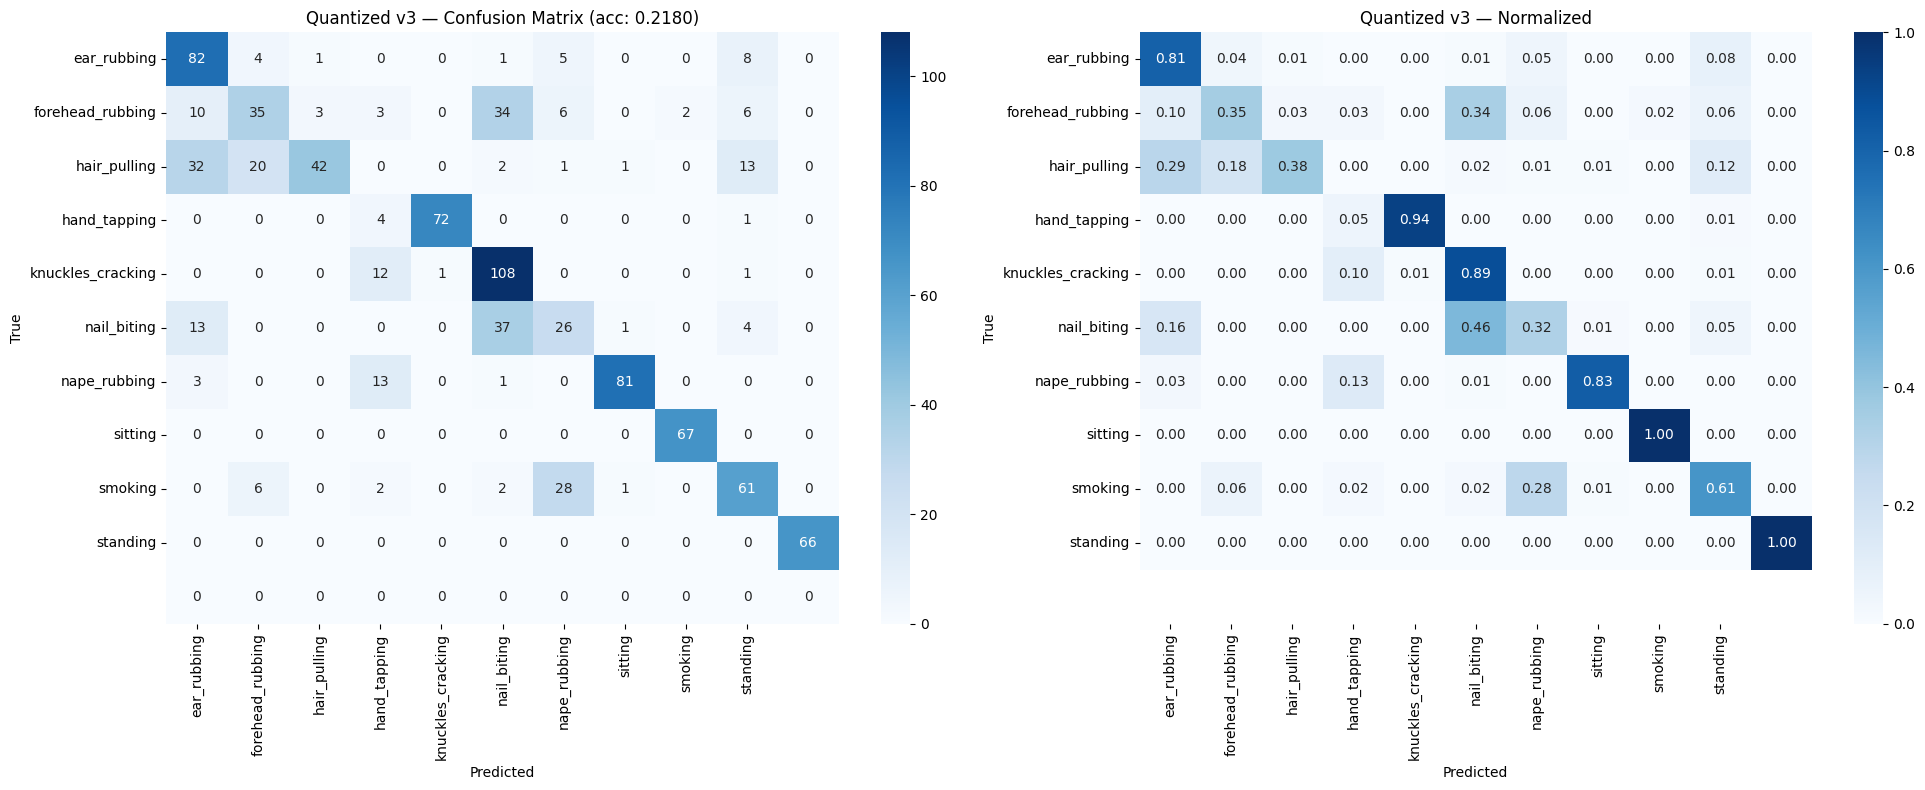

ValueError: Number of classes, 11, does not match size of target_names, 10. Try specifying the labels parameter

In [7]:
cm = confusion_matrix(y_test, quant_pred_classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ACTIVITIES,
            yticklabels=ACTIVITIES, ax=ax1)
ax1.set_title(f'Quantized v3 — Confusion Matrix (acc: {quant_acc:.4f})')
ax1.set_ylabel('True')
ax1.set_xlabel('Predicted')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=ACTIVITIES,
            yticklabels=ACTIVITIES, ax=ax2)
ax2.set_title('Quantized v3 — Normalized')
ax2.set_ylabel('True')
ax2.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(Path('../results') / 'quantized_v3_confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_test, quant_pred_classes, target_names=ACTIVITIES, digits=4))

## 5. Generate C Headers

In [8]:
# --- config.h ---
# Note: the embedded code needs to:
#   1. Read raw 6 sensor values (Ax, Ay, Az, Gx, Gy, Gz)
#   2. Compute Acc_mag = sqrt(Ax^2 + Ay^2 + Az^2)
#   3. Compute Gyro_mag = sqrt(Gx^2 + Gy^2 + Gz^2)
#   4. Normalize all 8 values using SENSOR_MEAN and SENSOR_STD
#   5. Quantize to INT8

config_h = f"""#ifndef CONFIG_H
#define CONFIG_H

// Activity Recognition Configuration (v3)
// Model: IDCNN with per-user normalization + magnitude features
// Activities: {NUM_CLASSES}

#define NUM_CLASSES {NUM_CLASSES}
#define NUM_RAW_FEATURES 6
#define NUM_FEATURES {NUM_FEATURES}  // 6 raw + 2 magnitude
#define WINDOW_SIZE {WINDOW_SIZE}
#define SAMPLING_RATE {SAMPLING_RATE}

// Feature order: Ax_w, Ay_w, Az_w, Gx_w, Gy_w, Gz_w, Acc_mag, Gyro_mag
// Acc_mag = sqrt(Ax^2 + Ay^2 + Az^2)
// Gyro_mag = sqrt(Gx^2 + Gy^2 + Gz^2)

// Global normalization parameters (applied after per-user norm during training)
// For deployment: use these directly on raw sensor data + computed magnitudes
const float SENSOR_MEAN[{NUM_FEATURES}] = {{{', '.join(f'{v:.6f}f' for v in SENSOR_MEAN)}}};
const float SENSOR_STD[{NUM_FEATURES}] = {{{', '.join(f'{v:.6f}f' for v in SENSOR_STD)}}};

// Quantization parameters (INT8)
const float INPUT_SCALE = {input_scale}f;
const int8_t INPUT_ZERO_POINT = {input_zero_point};
const float OUTPUT_SCALE = {output_scale}f;
const int8_t OUTPUT_ZERO_POINT = {output_zero_point};

// Activity labels
const char* ACTIVITY_LABELS[{NUM_CLASSES}] = {{
{chr(10).join(f'    "{act}",' for act in ACTIVITIES)}
}};

#endif // CONFIG_H
"""

config_path = MODEL_DIR / 'config.h'
config_path.write_text(config_h)
print(f'Saved {config_path}')
print(config_h)

Saved ../models/config.h
#ifndef CONFIG_H
#define CONFIG_H

// Activity Recognition Configuration (v3)
// Model: IDCNN with per-user normalization + magnitude features
// Activities: 10

#define NUM_CLASSES 10
#define NUM_RAW_FEATURES 6
#define NUM_FEATURES 8  // 6 raw + 2 magnitude
#define WINDOW_SIZE 128
#define SAMPLING_RATE 50

// Feature order: Ax_w, Ay_w, Az_w, Gx_w, Gy_w, Gz_w, Acc_mag, Gyro_mag
// Acc_mag = sqrt(Ax^2 + Ay^2 + Az^2)
// Gyro_mag = sqrt(Gx^2 + Gy^2 + Gz^2)

// Global normalization parameters (applied after per-user norm during training)
// For deployment: use these directly on raw sensor data + computed magnitudes
const float SENSOR_MEAN[8] = {0.000878f, 0.001624f, 0.000808f, 0.000055f, -0.000163f, 0.000406f, 1.641183f, 1.070511f};
const float SENSOR_STD[8] = {1.000287f, 1.000545f, 1.000286f, 0.999537f, 0.997873f, 0.996105f, 0.554387f, 1.357964f};

// Quantization parameters (INT8)
const float INPUT_SCALE = 0.11099183559417725f;
const int8_t INPUT_ZERO_POINT = -5;

In [9]:
# --- model_data.h ---
model_bytes = tflite_model

hex_lines = []
for i in range(0, len(model_bytes), 12):
    chunk = model_bytes[i:i+12]
    hex_str = ', '.join(f'0x{b:02x}' for b in chunk)
    hex_lines.append(f'  {hex_str},')

model_data_h = f"""#ifndef MODEL_DATA_H
#define MODEL_DATA_H

// TFLite model data (INT8 quantized)
// Model: IDCNN v3
// Size: {len(model_bytes):,} bytes
// Activities: {NUM_CLASSES}
// Features: {NUM_FEATURES} (6 raw + 2 magnitude)

alignas(8) const unsigned char activity_model_data[] = {{
{chr(10).join(hex_lines)}
}};

const unsigned int activity_model_data_len = {len(model_bytes)};

#endif // MODEL_DATA_H
"""

model_data_path = MODEL_DIR / 'model_data.h'
model_data_path.write_text(model_data_h)
print(f'Saved {model_data_path} ({len(model_data_h):,} bytes)')
print(f'Model binary: {len(model_bytes):,} bytes')

Saved ../models/model_data.h (603,711 bytes)
Model binary: 97,848 bytes


## 6. Summary

In [10]:
quant_report = {
    'best_model': 'IDCNN_v3',
    'original_accuracy': float(orig_acc),
    'quantized_accuracy': float(quant_acc),
    'accuracy_drop': float(orig_acc - quant_acc),
    'original_size_kb': orig_size,
    'quantized_size_kb': quant_size,
    'size_reduction_pct': (1 - quant_size/orig_size) * 100,
    'model_bytes': len(model_bytes),
    'input_scale': float(input_scale),
    'input_zero_point': int(input_zero_point),
    'output_scale': float(output_scale),
    'output_zero_point': int(output_zero_point),
    'num_classes': NUM_CLASSES,
    'num_features': NUM_FEATURES,
    'activities': ACTIVITIES,
}

with open(MODEL_DIR / 'quantization_report_v3.pkl', 'wb') as f:
    pickle.dump(quant_report, f)

print('=' * 55)
print('QUANTIZATION v3 SUMMARY')
print('=' * 55)
print(f'Model:              IDCNN v3')
print(f'Activities:         {NUM_CLASSES}')
print(f'Features:           {NUM_FEATURES} (6 raw + 2 magnitude)')
print(f'Original accuracy:  {orig_acc:.4f}')
print(f'Quantized accuracy: {quant_acc:.4f}')
print(f'Accuracy drop:      {(orig_acc - quant_acc)*100:.2f}%')
print(f'Original size:      {orig_size:.1f} KB')
print(f'Quantized size:     {quant_size:.1f} KB')
print(f'Size reduction:     {(1 - quant_size/orig_size)*100:.1f}%')
print(f'Model binary:       {len(model_bytes):,} bytes')
print(f'\nGenerated files:')
print(f'  models/config.h')
print(f'  models/model_data.h')
print(f'  models/activity_model_quantized_v3.tflite')
print(f'\nNote: embedded code must compute Acc_mag and Gyro_mag')
print(f'before feeding to the model (see config.h comments).')

QUANTIZATION v3 SUMMARY
Model:              IDCNN v3
Activities:         10
Features:           8 (6 raw + 2 magnitude)
Original accuracy:  0.2072
Quantized accuracy: 0.2180
Accuracy drop:      -1.08%
Original size:      880.6 KB
Quantized size:     95.6 KB
Size reduction:     89.1%
Model binary:       97,848 bytes

Generated files:
  models/config.h
  models/model_data.h
  models/activity_model_quantized_v3.tflite

Note: embedded code must compute Acc_mag and Gyro_mag
before feeding to the model (see config.h comments).
